# Exercise 2:Random walks

## 2.1
**Compute the following 1D integral via Monte Carlo** 
$$I = \int_0^1 \frac{\pi}{2}\cos(\pi x/2) dx = 1$$ 
1. **sampling a uniform distribution in $[0,1]$**
2. **using importance sampling (i.e. sampling a non-uniform probability in $[0,1]$)**


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

To sample the integral with the standard mean method I just applied the data blocking method, which I implemented using the same struct as exercise 1,for 100 blocks with 10000 steps each. At each step I generated a value of $x$ between 0 and 1, computed $f(x)$, and incremented the sum. The final estimate is very precise, as we can see from the blue curve in the plot below, with error values ranging from $\sim$ 0,1% to $\sim$ 0.01% from the first to the last block. 
We can see this a sampling the integral $\int_0^1 f(x)p(x)dx$ with $p(x)$=1.
The idea of importance sampling is that we don't necessarily need to impose $p(x)=1$, but rather we could find a better probability distribution to sample from in order to get a better estimate of the integral. Usually, the best results are obtained by sampling probability distributions that are similar to the integrand function. 
I tried two possibilities:
- $\frac{3}{2}(1-x^2)$. I chose this because the parabolic shape resembles the cosine between 0 and 1, however I decided to sample it using the accept-reject method since inverting its cumulative could result in a very long expression.
- $d(x)=1-\frac{\pi}{2}(x-0.5)$ this is the normalized 1st order expansion of the integrand around the midpoint of the interval (0.5), and I sampled it with the inverse cumulative method. Even though it lacks the similarity in shape, we can see that it approximates the integrand better than the first case especially close to 0.

Text(0, 0.5, 'Error')

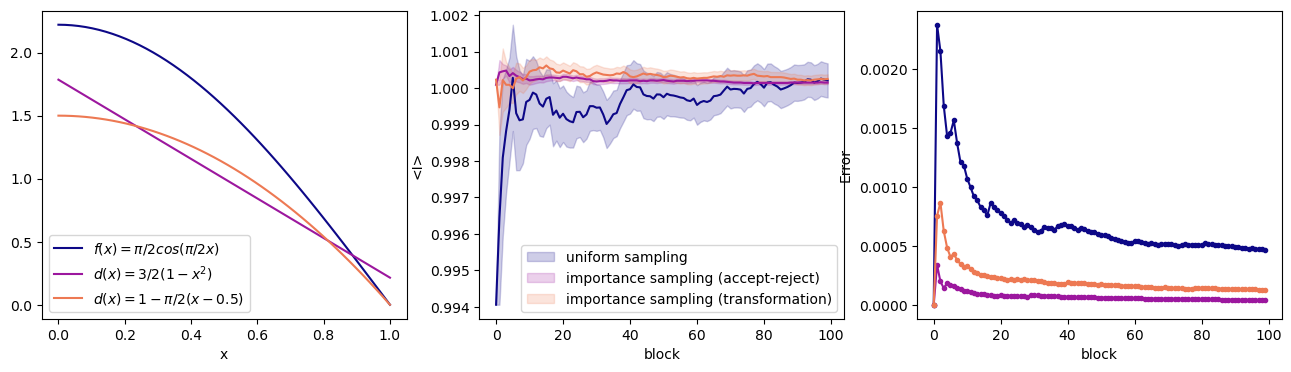

In [141]:
df = pd.read_csv("./OUTPUT/integral_uniform.csv",sep='\t')
df1= pd.read_csv("./OUTPUT/integral_IS_ar.csv",sep='\t')
df2= pd.read_csv("./OUTPUT/integral_IS_inv.csv",sep='\t')
fig,ax = plt.subplots(1,3,figsize=(16,4))

x=np.linspace(0,1)
y=np.pi *0.5*np.sqrt(2)*np.cos(np.pi*0.5*x)
colors =  plt.get_cmap("plasma", 4)
y2=3*0.5*(1-x**2)
y1= 1-np.pi*0.5*(x-0.5)
ax[0].plot(x,y,color=colors(0),label = r'$f(x)=\pi /2 cos(\pi/2 x)$')
ax[0].plot(x,y1,color=colors(1),label = r'$d(x)=3/2(1-x^2)$')
ax[0].plot(x,y2,color=colors(2),label = r'$d(x)=1-\pi /2(x-0.5)$')
ax[0].legend()
ax[0].set_xlabel('x')
ax[1].plot(df['block'],df['block_ave'],color=colors(0))
ax[1].fill_between(df['block'],df['block_ave']-df['err'],df['block_ave']+df['err'],alpha=0.2,label='uniform sampling',color=colors(0))

ax[1].plot(df1['block'],df1['block_ave'],color=colors(1))
ax[1].fill_between(df1['block'],df1['block_ave']-df1['err'],df1['block_ave']+df1['err'],alpha=0.2,color=colors(1),label='importance sampling (accept-reject)')

ax[1].plot(df2['block'],df2['block_ave'],color=colors(2))
ax[1].fill_between(df2['block'],df2['block_ave']-df2['err'],df2['block_ave']+df2['err'],color=colors(2),alpha=0.2,label='importance sampling (transformation)')
ax[1].legend()
ax[1].set_xlabel('block')
ax[1].set_ylabel('<I>')

ax[2].plot(df['block'],df['err'],color=colors(0),marker='.')
ax[2].plot(df1['block'],df1['err'],color=colors(1),marker='.')
ax[2].plot(df2['block'],df2['err'],color=colors(2),marker='.')
ax[2].set_xlabel('block')
ax[2].set_ylabel('Error')

As expected, using importance sampling significantly improves the integral estimation and reduces the errors significantly. The parabolic trial function is especially effective, since it performs the best in spite of the potential ineffectiveness of the accept-reject method.

## 2.2

In [166]:
from scipy.optimize import curve_fit
def plot_RW_fit(rw_type,f):

    df1 = pd.read_csv(f"./OUTPUT/RW_{rw_type}.csv", sep="\t")
    df2 = pd.read_csv(f"./OUTPUT/{rw_type}_distance.csv", sep="\t")

    fig = plt.figure(figsize=(16, 7))

    ax1 = fig.add_subplot(121, projection='3d')

    id_values = df1['walk_id'].unique()
    colors = plt.get_cmap("plasma", len(id_values))
    for i in id_values:
        ax1.plot(df1[df1['walk_id']==i]['x'], df1[df1['walk_id']==i]['y'],df1[df1['walk_id']==i]['z'],
                 label=f"Walk {i+1}", color=colors(i))
    
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.set_zlabel("Z")
    ax1.set_title("10 Random Walks")
    
    
    ax2 = fig.add_subplot(122)
    colors2 = plt.get_cmap("plasma", 4)
    x_vals = np.linspace(df2['step'].min(), df2['step'].max(), 100)
    par,cov = curve_fit(f,x_vals,df2['block_ave'])
    print(par)
    fit = f(x_vals,par)
    ax2.plot(x_vals, f(x_vals,par), '--', label=f'k={par}',color=colors2(0))
    
    ax2.errorbar(df2['step'], df2['block_ave'], yerr=df2['err'],
                 fmt='o', markersize=4, label=r"$\sqrt{<r_N^2>}$",color=colors2(2))
    
    ax2.set_xlabel("Step")
    ax2.set_ylabel("Distance")
    ax2.set_title("Mean Distance")
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    return fit



[0.93023412]


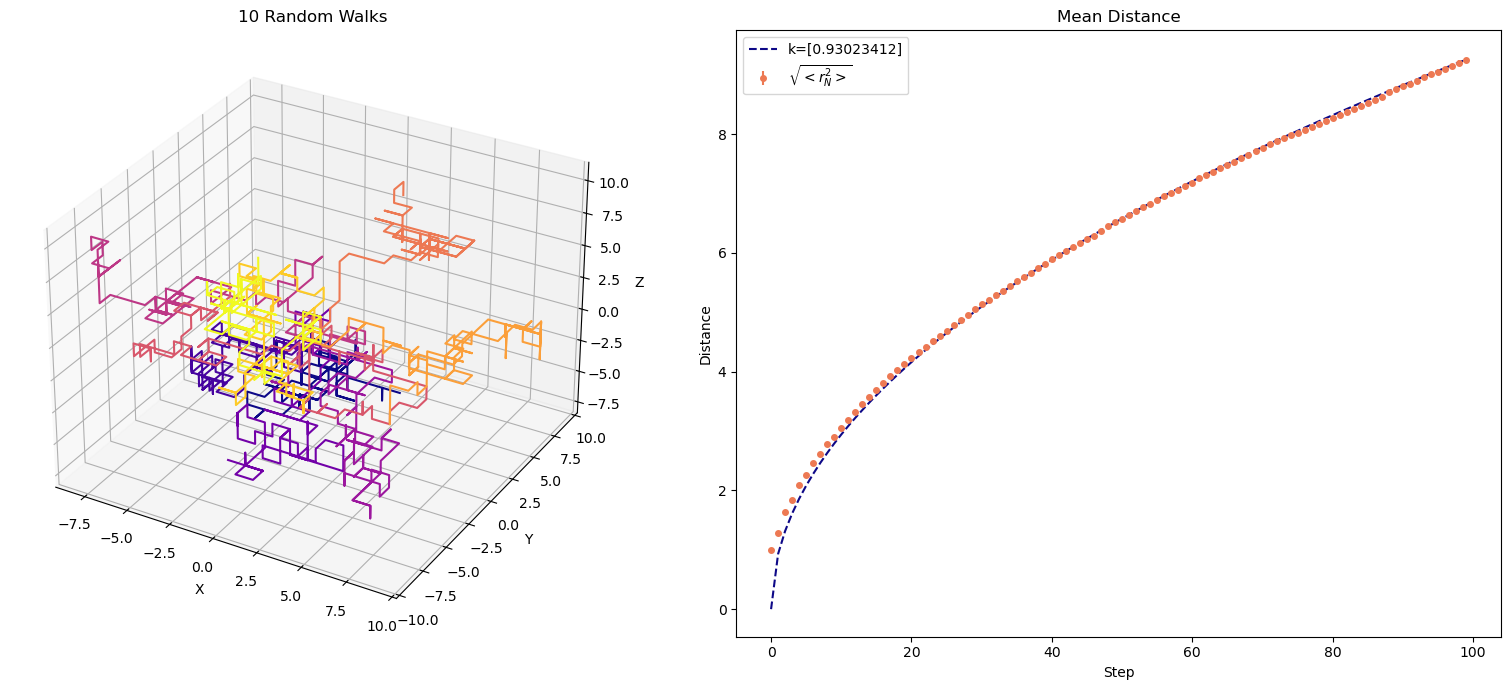

[0.9242215]


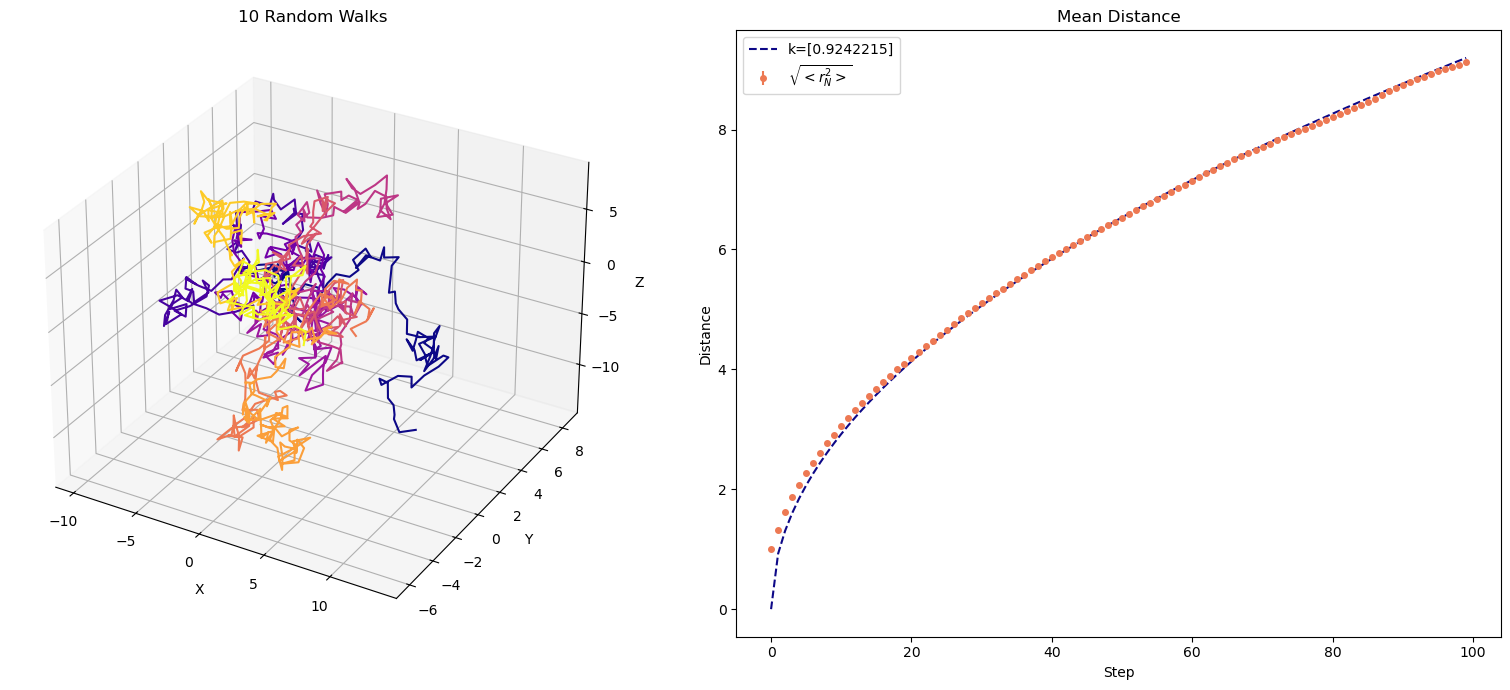

In [167]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def model(x,k):
    return k*np.sqrt(x)
fit1=plot_RW_fit('latt',model)
fit2=plot_RW_fit('cont',model)


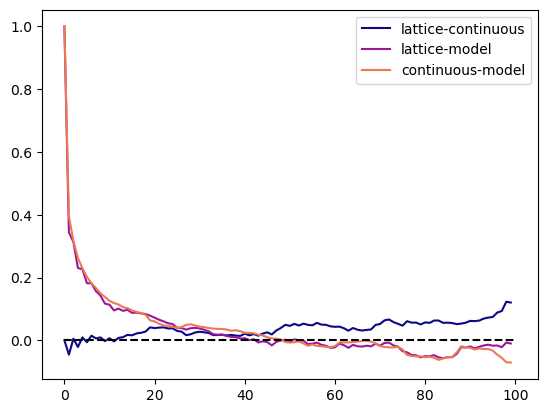

In [169]:
#residuals
dfl = pd.read_csv(f"./OUTPUT/latt_distance.csv", sep="\t")
dfc = pd.read_csv(f"./OUTPUT/cont_distance.csv", sep="\t")
    
x_vals = np.linspace(dfl['step'].min(), dfl['step'].max(), 100)
y_vals = np.sqrt(x_vals)
colors = plt.get_cmap("plasma", 4)
plt.plot(dfl['step'],dfl['block_ave']-dfc['block_ave'],label='lattice-continuous',color=colors(0))
plt.plot(dfl['step'],dfl['block_ave']-fit1,label='lattice-model',color=colors(1))
plt.plot(dfc['step'],dfc['block_ave']-fit2,label='continuous-model',color=colors(2))
plt.hlines(0,0,100,color='black',linestyle='dashed')
plt.legend()